In [1]:
# Step 8: Load and inspect in python

import pandas as pd

df = pd.read_csv("pcos_classifier_input.csv", index_col = 0)
df.shape

(6, 33290)

In [2]:
x = df.drop(columns=["condition"])
y = df["condition"]

print(x.shape)
print(y.value_counts())
            

(6, 33289)
condition
control    3
PCOS       3
Name: count, dtype: int64


In [3]:
# Step 9: Build the leak-free classifier with LOOCV

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func = f_classif, k= 30)),
    ("classifier", LogisticRegression(max_iter = 1000))
])

loo = LeaveOneOut()
scores = cross_val_score(pipeline, x, y, cv=loo)
scores
    


C:\Users\adeol\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  346   807  1902  2990  3245  3817  4564  4866  4991  5040  5858  6011
  6112  6599  6942  7802  7978  8086  8530  8578  8620  8809  9276  9920
 10116 10200 10567 10622 10682 10884 11277 11549 11765 11816 11837 11936
 11939 12322 12814 12819 12866 13014 13060 13258 13261 13274 13287 13297
 13312 13323 13354 13404 13728 13881 13974 14143 14241 14432 14522 14665
 14682 14862 14961 15035 15655 15882 15899 15905 15945 15986 16073 16079
 16089 16096 16113 16117 16137 16167 16173 16188 16245 16258 16337 16403
 16565 16634 16683 16825 16828 16877 16890 16894 16951 17145 17180 17188
 17195 17204 17205 17222 17226 17300 17368 17407 17409 17459 17467 17483
 17502 17604 17642 17685 17728 17754 17821 17931 17977 18010 18050 18069
 18105 18132 18161 18174 18216 18260 18264 18371 18389 18412 18416 18434
 18500 18534 18540 18578 18753 18755 18794 18893 18899 18928 18929 18933
 18

array([0., 0., 0., 0., 0., 0.])

In [4]:
# Step 10: Verify the scores result

from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(pipeline, x, y, cv= loo)

results_df = pd.DataFrame({
    "sample": x.index,
    "true_label": y.values,
    "predicted_labels": predictions
})

results_df



C:\Users\adeol\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  346   807  1902  2990  3245  3817  4564  4866  4991  5040  5858  6011
  6112  6599  6942  7802  7978  8086  8530  8578  8620  8809  9276  9920
 10116 10200 10567 10622 10682 10884 11277 11549 11765 11816 11837 11936
 11939 12322 12814 12819 12866 13014 13060 13258 13261 13274 13287 13297
 13312 13323 13354 13404 13728 13881 13974 14143 14241 14432 14522 14665
 14682 14862 14961 15035 15655 15882 15899 15905 15945 15986 16073 16079
 16089 16096 16113 16117 16137 16167 16173 16188 16245 16258 16337 16403
 16565 16634 16683 16825 16828 16877 16890 16894 16951 17145 17180 17188
 17195 17204 17205 17222 17226 17300 17368 17407 17409 17459 17467 17483
 17502 17604 17642 17685 17728 17754 17821 17931 17977 18010 18050 18069
 18105 18132 18161 18174 18216 18260 18264 18371 18389 18412 18416 18434
 18500 18534 18540 18578 18753 18755 18794 18893 18899 18928 18929 18933
 18

,sample,true_label,predicted_labels
0,N20,control,PCOS
1,N21,control,PCOS
2,N25,control,PCOS
3,P14,PCOS,control
4,P15,PCOS,control
5,P16,PCOS,control


In [5]:
# Step 11: ask the pipeline what order its classes are in, and use that to build the column labels automatically

pipeline.fit(x, y)
class_order = pipeline.named_steps["classifier"].classes_
class_order

array(['PCOS', 'control'], dtype=object)

In [6]:
# Step 12: Check the model's confidence not just the final answer

from sklearn.model_selection import cross_val_predict

probabilities = cross_val_predict(pipeline, x, y, cv=loo, method = "predict_proba")

prob_df = pd.DataFrame(probabilities, columns= [f"prob_{c}" for c in class_order])
prob_df["sample"] = x.index
prob_df["true_label"] = y.values
prob_df["predicted_label"] = predictions

prob_df

C:\Users\adeol\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  346   807  1902  2990  3245  3817  4564  4866  4991  5040  5858  6011
  6112  6599  6942  7802  7978  8086  8530  8578  8620  8809  9276  9920
 10116 10200 10567 10622 10682 10884 11277 11549 11765 11816 11837 11936
 11939 12322 12814 12819 12866 13014 13060 13258 13261 13274 13287 13297
 13312 13323 13354 13404 13728 13881 13974 14143 14241 14432 14522 14665
 14682 14862 14961 15035 15655 15882 15899 15905 15945 15986 16073 16079
 16089 16096 16113 16117 16137 16167 16173 16188 16245 16258 16337 16403
 16565 16634 16683 16825 16828 16877 16890 16894 16951 17145 17180 17188
 17195 17204 17205 17222 17226 17300 17368 17407 17409 17459 17467 17483
 17502 17604 17642 17685 17728 17754 17821 17931 17977 18010 18050 18069
 18105 18132 18161 18174 18216 18260 18264 18371 18389 18412 18416 18434
 18500 18534 18540 18578 18753 18755 18794 18893 18899 18928 18929 18933
 18

,prob_PCOS,prob_control,sample,true_label,predicted_label
0,0.552432,0.447568,N20,control,PCOS
1,0.822892,0.177108,N21,control,PCOS
2,0.725003,0.274997,N25,control,PCOS
3,0.370269,0.629731,P14,PCOS,control
4,0.383833,0.616167,P15,PCOS,control
5,0.102231,0.897769,P16,PCOS,control


In [7]:
# Step 13: Fit the final model on all data and extract selected genes

pipeline.fit(x, y)

selector = pipeline.named_steps["feature_selection"]
selected_mask = selector.get_support()
selected_genes = x.columns[selected_mask]

len(selected_genes)
selected_genes


Index(['ENSG00000042781', 'ENSG00000093134', 'ENSG00000110811',
       'ENSG00000112511', 'ENSG00000129173', 'ENSG00000129474',
       'ENSG00000131142', 'ENSG00000141198', 'ENSG00000148343',
       'ENSG00000169221', 'ENSG00000171049', 'ENSG00000177427',
       'ENSG00000196376', 'ENSG00000198049', 'ENSG00000223305',
       'ENSG00000231699', 'ENSG00000233008', 'ENSG00000234042',
       'ENSG00000234961', 'ENSG00000243107', 'ENSG00000255367',
       'ENSG00000259240', 'ENSG00000260165', 'ENSG00000262304',
       'ENSG00000263982', 'ENSG00000264456', 'ENSG00000271428',
       'ENSG00000275097', 'ENSG00000278733', 'ENSG00000282418'],
      dtype='str')

In [8]:
# Step 14: Setup the shap explainer

import shap

x_selected = selector.transform(x)
x_selected_df = pd.DataFrame(x_selected, columns= selected_genes, index= x.index)

classifier = pipeline.named_steps["classifier"]

explainer = shap.LinearExplainer(classifier, x_selected_df)
shap_values = explainer(x_selected_df)

print(shap_values)
shap_values.values.shape

.values =
array([[ 0.09175766,  0.52991532,  0.06037804,  0.00325485,  0.43090432,
         0.01381685,  0.50112848,  0.01447088,  0.00919018,  0.00870751,
         0.80560926,  0.03074597,  0.10551348,  0.10551348,  0.04453806,
         0.04864857,  0.07244687,  0.04793659,  0.02567459,  0.18085979,
         0.08192423,  0.10887602,  0.04835814,  0.16089075,  0.10067724,
         0.21452385,  0.09117966,  0.0488354 ,  0.10887602,  0.108213  ],
       [ 0.09175766,  0.52991532,  0.08545427,  0.0029226 ,  0.43090432,
         0.01905698,  0.36539598,  0.02506272,  0.01119157,  0.00742083,
         0.80560926,  0.03942171,  0.06804152,  0.06804152,  0.04453806,
         0.04119558,  0.07244687,  0.06886579,  0.03042518,  0.18085979,
         0.12436125,  0.10887602,  0.06754652,  0.18650982,  0.10067724,
         0.21452385,  0.09117966,  0.05203618,  0.10887602,  0.0950054 ],
       [ 0.09175766,  0.52991532,  0.09845484,  0.00389686,  0.43090432,
         0.01645647,  0.34699696,  0.02

(6, 30)

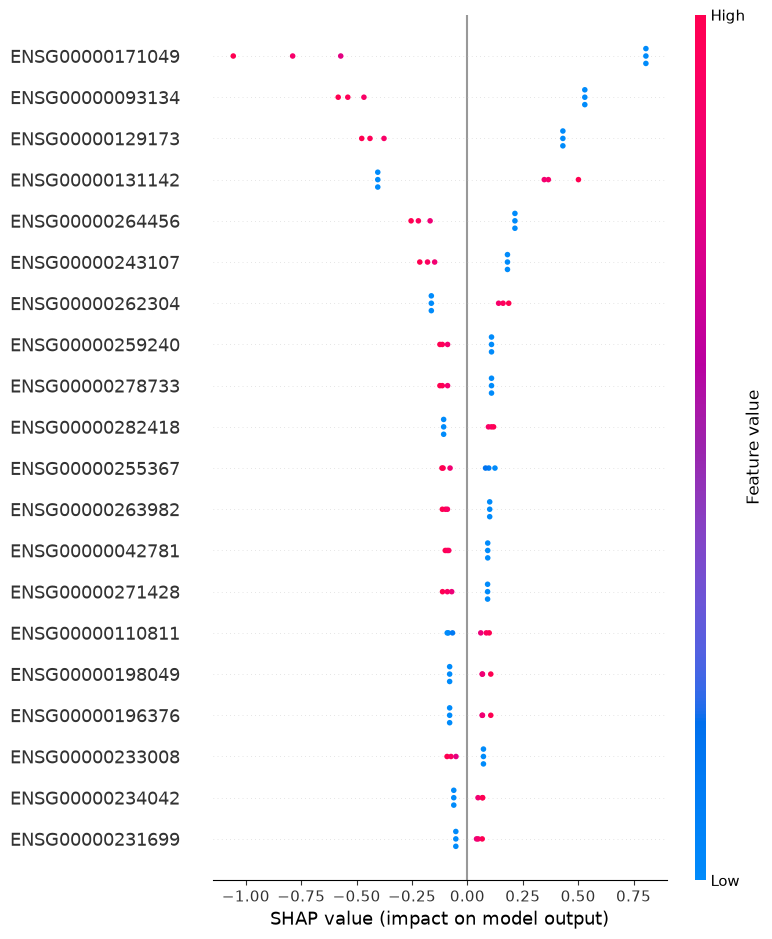

In [9]:
# Step 15: Build the shap summary plot

shap.summary_plot(shap_values, x_selected_df)



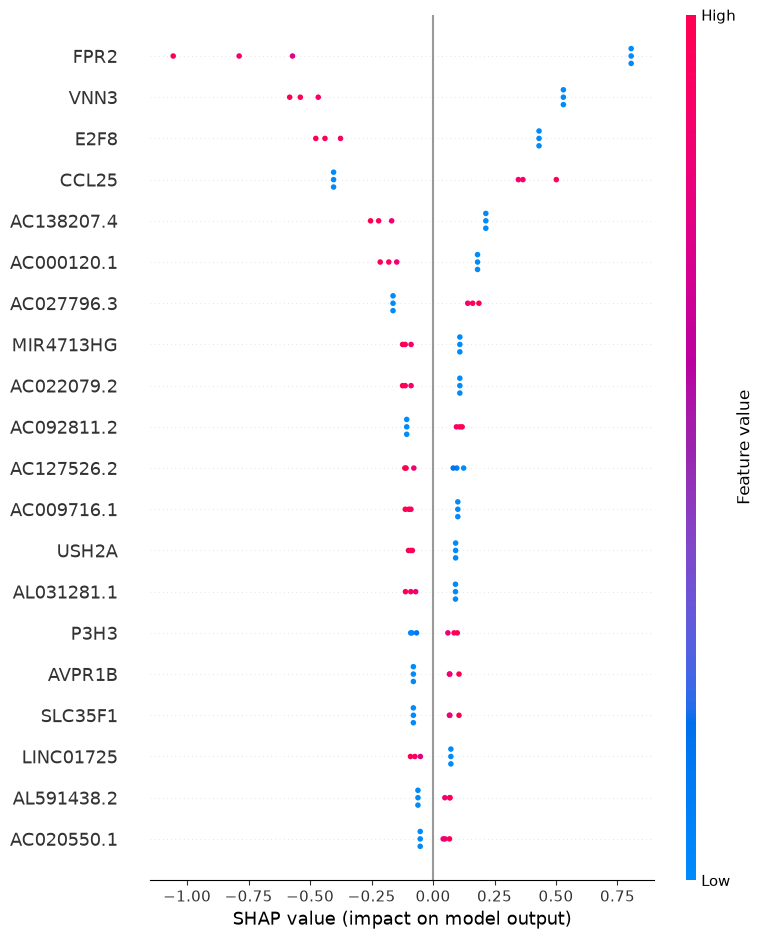

In [10]:
# Step 16: Map Ensembl IDs to gene symbols and rebuild the plot with readable names

gene_lookup = pd.read_csv("gene_lookup.csv")

symbol_map = dict(zip(gene_lookup["ENSEMBL"], gene_lookup["SYMBOL"]))
readable_genes = [symbol_map.get(g, g) for g in selected_genes]

x_selected_df_readable = x_selected_df.copy()
x_selected_df_readable.columns = readable_genes

shap.summary_plot(shap_values.values, x_selected_df_readable)

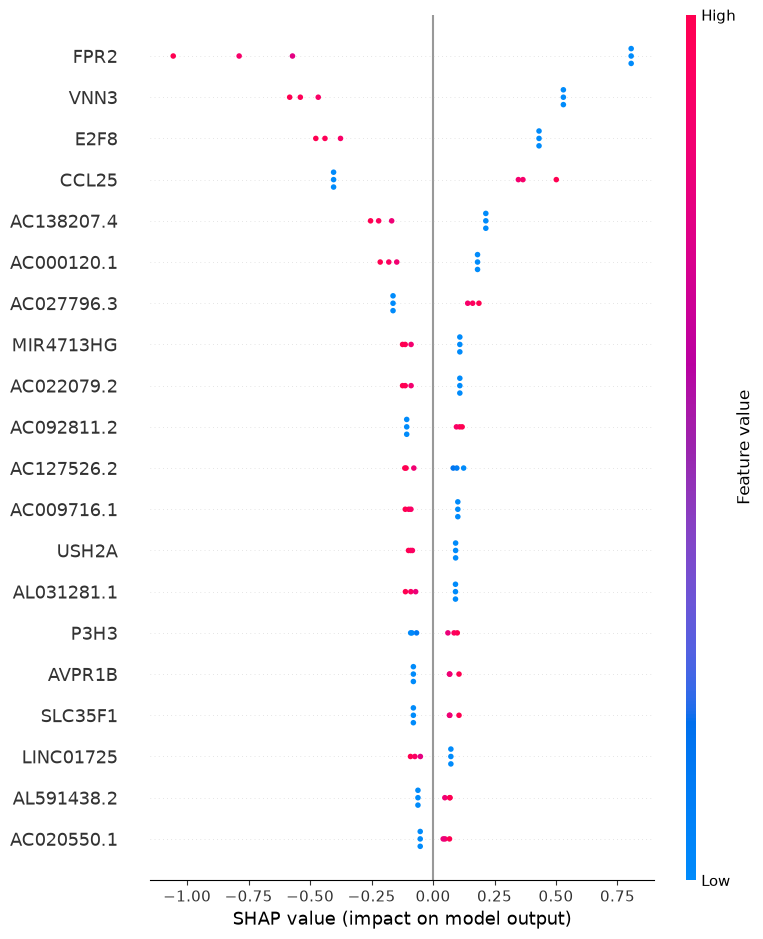

In [11]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values.values, x_selected_df_readable, show = False)
plt.savefig("shap_summary_plot.png", bbox_inches = "tight", dpi=300)
plt.show()

In [12]:
# Step 17: Direction check

sample_margin = classifier.decision_function(x_selected_df.iloc[[0]])
sample_shap_sum = shap_values.base_values[0] + shap_values.values[0].sum()

print(sample_margin, sample_shap_sum)
print(class_order)


[4.19475066] 4.194750658639693
['PCOS' 'control']


C:\Users\adeol\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [13]:
# Step 18 : Map the SHAP-selected genes to STRING (done in R)

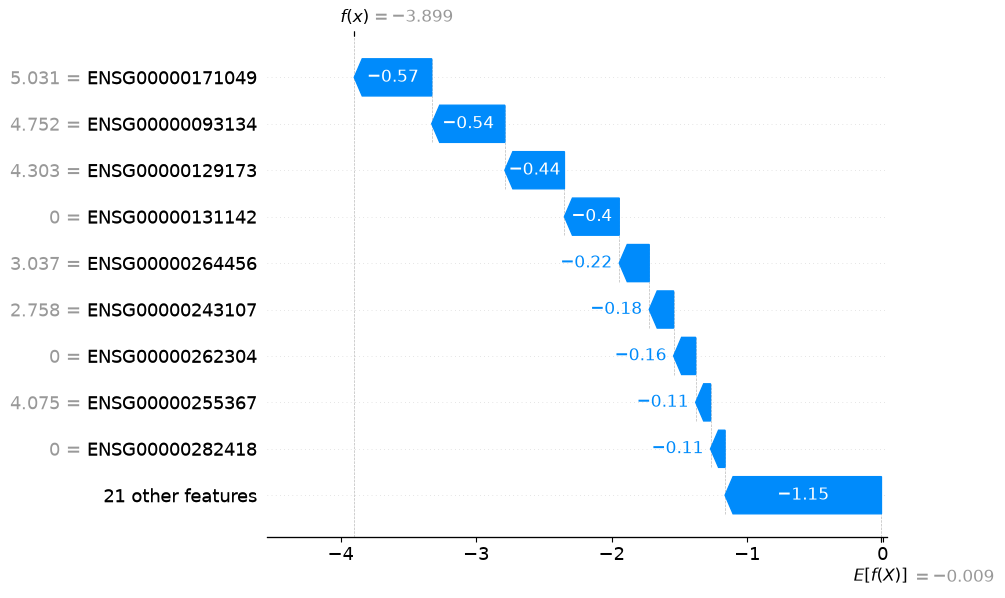

In [14]:
# Step 19: Individual-sample SHAP explanation

sample_name = "P16"
sample_index = list(x_selected_df_readable.index).index(sample_name)

shap.plots.waterfall(shap_values[sample_index])

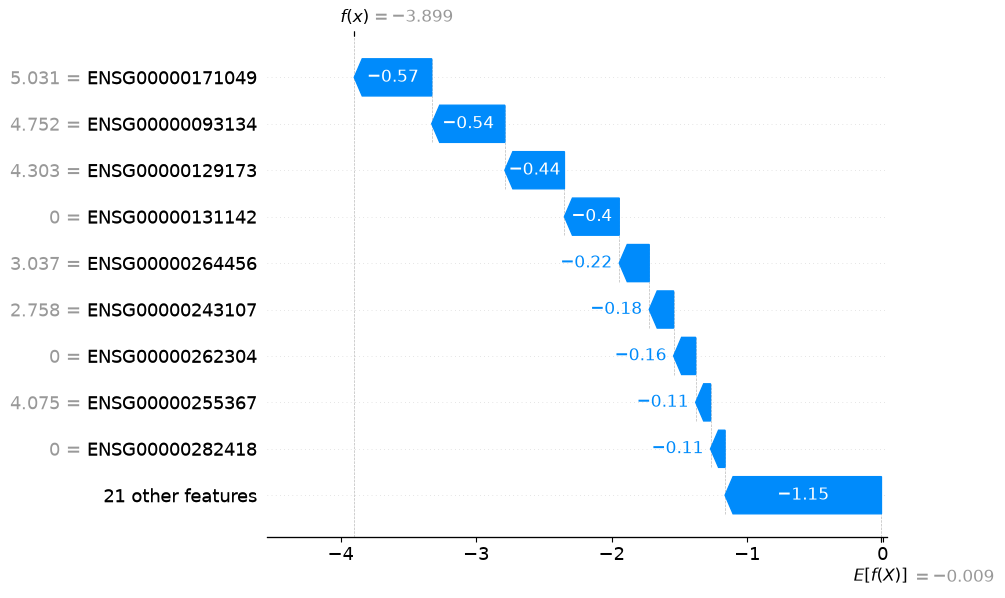

In [15]:
# Save the waterfall plot

import matplotlib.pyplot as plt

shap.plots.waterfall(shap_values[sample_index], show=False)
plt.savefig("shap_waterfall_P16.png", bbox_inches="tight", dpi=300)
plt.show()

In [16]:
# Step 20: Run SHAP-identified genes through NetworkAnalyst (Run on the browser)

